In [1]:
import numpy as np
import pandas as pd
import time
import cv2
import matplotlib.pyplot as plt
import os

In [2]:
import json

In [3]:
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder,filename))
        if img is not None:
            images.append(img)
    return images

In [4]:
images1=load_images_from_folder("../InDir/NonWaterIm")
images2=load_images_from_folder("../InDir/WaterIm")

In [5]:
images1=np.array(images1)
images2=np.array(images2)

In [6]:
(winW, winH) = (48,48)

In [7]:
def sliding_window(image, stepSize, windowSize):
	# slide a window across the image
	for y in range(0, image.shape[0], stepSize):
		for x in range(0, image.shape[1], stepSize):
#			print(y + windowSize[1])
			yield (x, y, image[y:y + windowSize[1], x:x + windowSize[0]])

In [8]:
def func(images):
    im=[]
    count=0
    for img1 in images:
        print(count)
        count=count+1;
        for (x, y, window) in sliding_window(img1, stepSize=32, windowSize=(winW, winH)):
            if window.shape[0] != winH or window.shape[1] != winW:
                continue
            #clone = img1.copy()
            #cv2.rectangle(clone, (x, y), (x + winW, y + winH), (0, 255, 0), 2)
            #x=cv2.resize(window, (224,224)) 
            im.append(window)
            #cv2.imshow("clone", clone)
            #cv2.imwrite(f'../InDir/train64/{i}.jpg',window)
            #cv2.waitKey(1)
            #time.sleep(0.025)
        #cv2.waitKey(0)
        #cv2.destroyAllWindows()
    return im

In [9]:
im1=func(images1)
im2=func(images2)
im1=np.asarray(im1)
im2=np.asarray(im2)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [10]:
im=np.concatenate((im1,im2),axis=0)

In [11]:
len(im)

54709

In [12]:
len(im2)

6286

In [13]:
y=np.zeros(len(im))
y[len(im1):]=1

In [14]:
y.shape

(54709,)

In [15]:
im = im.astype('float32')
im/=255

In [16]:
from sklearn.preprocessing import LabelEncoder
from keras.utils import np_utils
encoder = LabelEncoder()
encoder.fit(y)
y = encoder.transform(y)
y= np_utils.to_categorical(y)

Using TensorFlow backend.


In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(im, y, test_size=0.4, random_state=0)#train test random split

# Own Model

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense,Dropout,Activation,InputLayer

model = Sequential()
model.add(InputLayer((X_train[0].shape)))
model.add(Conv2D(64, (3,3), input_shape=(X_train[0].shape),padding='same'))
model.add(Conv2D(64, (3,3),padding='same'))
model.add(Dropout(0.2))
#model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, (3,3),padding='same'))
model.add(Conv2D(128, (3,3),padding='same'))
model.add(Dropout(0.2))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(256, (3,3),padding='same'))
model.add(Conv2D(256, (3,3),padding='same'))
model.add(Dropout(0.2))
model.add(MaxPooling2D(pool_size=(2,2)))


model.add(Conv2D(512, (3,3),padding='same'))
model.add(Conv2D(512, (3,3),padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())  # this converts our 3D feature maps to 1D feature vectors

model.add(Dense(64))
model.add(Dropout(0.2))
model.add(Dense(2))
model.add(Activation('softmax'))


Instructions for updating:
Colocations handled automatically by placer.
Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


In [18]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 48, 48, 64)        1792      
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 48, 48, 64)        36928     
_________________________________________________________________
dropout (Dropout)            (None, 48, 48, 64)        0         
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 24, 24, 64)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 24, 24, 128)       73856     
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 24, 24, 128)       147584    
_________________________________________________________________
dropout_1 (Dropout)          (None, 24, 24, 128)       0         
__________

In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [ ]:
model.fit(X_train,Y_train, batch_size=32, epochs=5, validation_split=0.3)

# Initialising VGG

In [19]:
import tensorflow.keras
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers

# Create the base model of VGG19
vgg19 = ResNet50(weights='imagenet', include_top=False, input_shape = ((48,48,3)))

C:\Users\user\.conda\envs\tcs\lib\site-packages\keras_applications\resnet50.py:265: UserWarning: The output shape of `ResNet50(include_top=False)` has been changed since Keras 2.2.0.
  warnings.warn('The output shape of `ResNet50(include_top=False)` '


# Transfer Learning with layer unfreezing

In [51]:
output = vgg19.layers[-1].output
output = tensorflow.keras.layers.Flatten()(output)
vgg_model = Model(vgg19.input, output)


input_shape = vgg_model.output_shape[1]
model = Sequential()
model.add(vgg_model)
model.add(Dense(512, activation='relu'))
#model.add(Dropout(0.3))
model.add(Dense(2, activation='sigmoid'))





flag=False
model.trainable = True
for layer in vgg_model.layers:
    if layer.name=='block1_conv1':
        flag=True
    layer.trainable = flag
    
import pandas as pd
pd.set_option('max_colwidth', -1)
layers = [(layer, layer.name, layer.trainable) for layer in vgg_model.layers]
pd.DataFrame(layers, columns=['Layer Type', 'Layer Name', 'Layer Trainable'])

,Layer Type,Layer Name,Layer Trainable
0,<tensorflow.python.keras.engine.training.Model object at 0x000001FA14869A20>,model_5,False
1,<tensorflow.python.keras.layers.core.Dense object at 0x000001FA16394B00>,dense_27,True


In [52]:
print(model.summary())

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
model_5 (Model)              (None, 8192)              23587712  
_________________________________________________________________
dense_27 (Dense)             (None, 2)                 16386     
Total params: 23,604,098
Trainable params: 16,386
Non-trainable params: 23,587,712
_________________________________________________________________
None


In [53]:


model.compile(loss='categorical_crossentropy',
              optimizer=optimizers.RMSprop(lr=1e-5),
              metrics=['accuracy'])             


In [54]:
print(model.summary())

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
model_5 (Model)              (None, 8192)              23587712  
_________________________________________________________________
dense_27 (Dense)             (None, 2)                 16386     
Total params: 23,604,098
Trainable params: 16,386
Non-trainable params: 23,587,712
_________________________________________________________________
None


In [55]:
for layer in model.layers:
    print(layer.output_shape)

(None, 8192)
(None, 2)


In [56]:
model.fit(X_train,Y_train, batch_size=128, epochs=10, validation_split=0.3)

Train on 22977 samples, validate on 9848 samples
Epoch 1/10
22977/22977 [==============================] - 344s 15ms/sample - loss: 0.4848 - acc: 0.7701 - val_loss: 0.6418 - val_acc: 0.8781
Epoch 2/10
22977/22977 [==============================] - 342s 15ms/sample - loss: 0.2684 - acc: 0.9039 - val_loss: 0.5589 - val_acc: 0.8823
Epoch 3/10
22977/22977 [==============================] - 341s 15ms/sample - loss: 0.1993 - acc: 0.9365 - val_loss: 0.5166 - val_acc: 0.8823
Epoch 4/10
22977/22977 [==============================] - 342s 15ms/sample - loss: 0.1488 - acc: 0.9563 - val_loss: 0.4723 - val_acc: 0.8823
Epoch 5/10
22977/22977 [==============================] - 341s 15ms/sample - loss: 0.1199 - acc: 0.9658 - val_loss: 0.4322 - val_acc: 0.8823
Epoch 6/10
22977/22977 [==============================] - 342s 15ms/sample - loss: 0.1048 - acc: 0.9694 - val_loss: 0.4005 - val_acc: 0.8823
Epoch 7/10
22977/22977 [==============================] - 341s 15ms/sample - loss: 0.0938 - acc: 0.9722 -

# Transfer Learning with no unfreezing

In [20]:
train_features = vgg19.predict(np.array(X_train), batch_size=256, verbose=1)
test_features = vgg19.predict(np.array(X_test), batch_size=256, verbose=1)

21884/21884 [==============================] - 218s 10ms/sample


In [26]:
vgg19.summary()

__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            (None, 48, 48, 3)    0                                            
__________________________________________________________________________________________________
conv1_pad (ZeroPadding2D)       (None, 54, 54, 3)    0           input_2[0][0]                    
__________________________________________________________________________________________________
conv1 (Conv2D)                  (None, 24, 24, 64)   9472        conv1_pad[0][0]                  
__________________________________________________________________________________________________
bn_conv1 (BatchNormalizationV1) (None, 24, 24, 64)   256         conv1[0][0]                      
__________________________________________________________________________________________________
activation

In [22]:
train_features.shape

(32825, 2, 2, 2048)

In [24]:
X_train.shape

(32825, 48, 48, 3)

In [44]:
train_features = np.reshape(train_features, (len(X_train), 512))
test_features = np.reshape(test_features, (len(X_test), 512))

# Add Dense and Dropout layers on top of VGG19 pre-trained
model = models.Sequential()
model.add(Dense(512, activation='relu', input_dim=512))
model.add(Dense(256, activation='relu', input_dim=512))
model.add(Dropout(0.5))
model.add(Dense(2, activation="softmax"))

# Compile the model
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.Adam(),
              metrics=['accuracy'])

In [45]:
for layer in model.layers:
    print(layer.output_shape)

(None, 512)
(None, 256)
(None, 256)
(None, 2)


In [38]:
model.fit(train_features,Y_train, batch_size=32, epochs=10, validation_split=0.3)

Train on 22977 samples, validate on 9848 samples
Instructions for updating:
Use tf.cast instead.
Instructions for updating:
Deprecated in favor of operator or tf.math.divide.
Epoch 1/10


InvalidArgumentError: Incompatible shapes: [32] vs. [32,2,2]
	 [[{{node metrics/acc/Equal}}]]



# Model Test

# Frozen

In [60]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
Y_test2=np.argmax(Y_test,axis=1)
Y_pred=model.predict_proba(test_features)
#Y_pred=model.predict_proba(X_test)
y_pred = np.argmax(Y_pred, axis=1)
acc=accuracy_score(Y_test2, y_pred)
print(acc)
print(confusion_matrix(Y_test2,y_pred))
print(classification_report(Y_test2,y_pred))

ValueError: Error when checking input: expected dense_1_input to have 2 dimensions, but got array with shape (21884, 2, 2, 2048)

# Unfrozen

In [59]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
Y_test2=np.argmax(Y_test,axis=1)
#Y_pred=model.predict_proba(test_features)
Y_pred=model.predict_proba(X_test)
y_pred = np.argmax(Y_pred, axis=1)
acc=accuracy_score(Y_test2, y_pred)
print(acc)
print(confusion_matrix(Y_test2,y_pred))
print(classification_report(Y_test2,y_pred))

ValueError: Error when checking input: expected dense_1_input to have 2 dimensions, but got array with shape (21884, 48, 48, 3)

In [30]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
Y_test2=np.argmax(Y_test,axis=1)
#Y_pred=model.predict_proba(test_features)
Y_pred=model.predict_proba(X_test)
y_pred = np.argmax(Y_pred, axis=1)
acc=accuracy_score(Y_test2, y_pred)
print(acc)
print(confusion_matrix(Y_test2,y_pred))
print(classification_report(Y_test2,y_pred))

KeyboardInterrupt: 

In [25]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
Y_test2=np.argmax(Y_test,axis=1)
#Y_pred=model.predict_proba(test_features)
Y_pred=model.predict_proba(X_test)
y_pred = np.argmax(Y_pred, axis=1)
acc=accuracy_score(Y_test2, y_pred)
print(acc)
print(confusion_matrix(Y_test2,y_pred))
print(classification_report(Y_test2,y_pred))

KeyboardInterrupt: 

In [36]:
model.save('../models/model_unfrozen_all.h5')

# Model Load

In [58]:
from tensorflow.keras.models import load_model
model = load_model('../models/model2.h5', compile=False)
model.load_weights('../models/model2.h5')

In [135]:
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import CustomObjectScope
from tensorflow.keras.initializers import glorot_uniform
with CustomObjectScope({'GlorotUniform': glorot_uniform()}):
        model = load_model('../models/model_unfrozen_all.h5')

Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


TypeError: Unexpected keyword argument passed to optimizer: learning_rate

# Image Load

In [53]:
img1=cv2.imread('../test/11.jpg',cv2.IMREAD_COLOR);
#img1 = img1.astype('float32')
#img1/=255
#img1 = cv2.resize(img1, (960, 540))  
#img1 = cv2.resize(img1, (1024,1024), interpolation=cv2.INTER_AREA)
(winW, winH) = (48,48)

In [54]:
def sliding_window(image, stepSize, windowSize):
	# slide a window across the image
	for y in range(0, image.shape[0], stepSize):
		for x in range(0, image.shape[1], stepSize):
#			print(y + windowSize[1])
			yield (x, y, image[y:y + windowSize[1], x:x + windowSize[0]])

In [55]:
img1.shape

(534, 800, 3)

In [56]:
steps=48
img1= np.pad(img1, pad_width=steps, mode='constant', constant_values=0)
img1=img1[:,:,steps:steps+3]
mask=np.zeros(np.asarray(img1).shape[:2])
mask.shape

(630, 896)

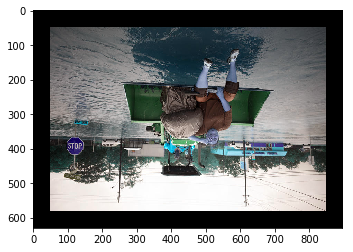

In [57]:
plt.imshow(img1)

In [58]:
for (x, y, window) in sliding_window(img1, stepSize=8, windowSize=(winW, winH)):
    if window.shape[0] != winH or window.shape[1] != winW:
        continue
    X= np.expand_dims(window, axis=0)
    pred = vgg19.predict(np.array(X), batch_size=32, verbose=1)
    pred = np.reshape(pred, (1,512))
    Y_pred=model.predict(pred)
    #Y_pred=model.predict(X)
    y_pred = np.argmax(Y_pred, axis=1)
    
    mask[y:y + winW, x:x + winH]+=np.full((48,48), y_pred)
    
    clone = img1.copy()
    val=int(255*y_pred[0])
    cv2.rectangle(clone, (x, y), (x + winW, y + winH), (0, 255,val), 2)
    cv2.imshow("clone", clone)
    #cv2.imshow("window",window)
    cv2.waitKey(1)
    #time.sleep(0.015)
cv2.waitKey(0)
cv2.destroyAllWindows()

1/1 [==============================] - 0s 102ms/sample


1/1 [==============================] - 0s 104ms/sample


1/1 [==============================] - 0s 101ms/sample


1/1 [==============================] - 0s 99ms/sample


KeyboardInterrupt: 

In [143]:
Y_pred

array([[0.04352845, 0.00024273]], dtype=float32)

In [95]:
img1=img1[steps:-steps,steps:-steps]
mask=mask[steps:-steps,steps:-steps]

In [96]:
maxval = np.amax(mask)
maxval

40.0

In [97]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
mask3= scaler.fit_transform(mask)
mask3*=255

In [115]:
mask2=mask/maxval

In [116]:
for i in range(img1.shape[:1][0]):
    for j in range(img1.shape[1:2][0]):
        if(mask2[i,j]>=0.0002):
            mask2[i][j]=255
        else:
            mask2[i,j]=0

In [128]:
cv2.imshow("mask", mask2)
cv2.waitKey(0)
#cv2.imshow("mask", thresh1)
#cv2.waitKey(0)
cv2.imshow("mask", mask3)
cv2.waitKey(0)
cv2.imshow("img",img1)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [118]:
ret,thresh1 = cv2.threshold(mask3,127,255,cv2.THRESH_BINARY)
cv2.imshow('win1', thresh1)
cv2.waitKey(0)  
cv2.destroyAllWindows()

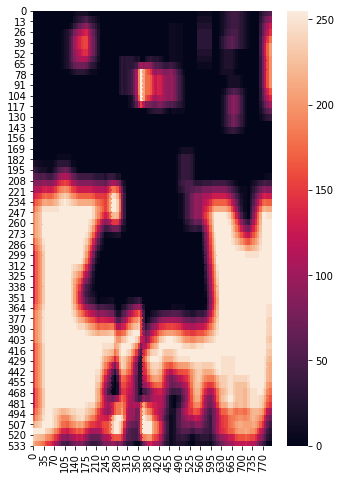

In [37]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(img1.shape[0]/100,img1.shape[1]/100))         # Sample figsize in inches
sns.heatmap(mask3,vmin=0, vmax=255)

In [149]:
cv2.imwrite(f'../prediction/53435.jpg',thresh1)

True

In [121]:
x=mask2.shape[0]*mask2.shape[1]
y=0
for i in range(mask2.shape[0]):
    for j in range(mask2.shape[1]):
        y=y+(mask2[i][j]/255)
print("Percentage of water in the image is: ", (y/x)*100);

Percentage of water in the image is:  47.79472810294728


In [59]:
cv2.destroyAllWindows()